In [3]:
import zipfile

with zipfile.ZipFile('/twitter_training.csv(1).zip') as zip_ref:
  zip_ref.extractall('.')

In [4]:
import os
print(os.listdir('.'))

['.config', 'twitter_training.csv', 'sample_data']


In [10]:
import pandas as pd
train = pd.read_csv('/twitter_training.csv(1).zip',header=None)
train.columns = ['id','company','sentiment','text']

In [14]:
#step 1 - import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection as model_selection
from sklearn .feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score,classification_report
from wordcloud import WordCloud

In [21]:
#load data
train = pd.read_csv('twitter_training.csv',header = None)
train.columns =['id','company','sentiment','text']

test = pd.read_csv('/twitter_validation.csv',header=None)
test.columns = ['id','company','sentiment','text']

In [25]:
#drop empty rows

train.dropna(inplace=True)
test.dropna(inplace=True)

print(train['sentiment'].value_counts())

print(train.shape)
print(test.shape)

sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64
(73996, 4)
(1000, 4)


In [31]:
# Clean the  text

import re
def clean_text(text):
  text = str(text).lower()
  text = re.sub(r'http\S+','',text) # remove links
  text = re. sub(r'@\w+','',text) # remove @mentions
  text = re.sub(r'[^a-z\s]','',text) # remove symbols
  return text

train['text'] = train['text'].apply(clean_text)
test['text'] = test['text'].apply(clean_text)
print(test)


       id              company   sentiment  \
0    3364             Facebook  Irrelevant   
1     352               Amazon     Neutral   
2    8312            Microsoft    Negative   
3    4371                CS-GO    Negative   
4    4433               Google     Neutral   
..    ...                  ...         ...   
995  4891  GrandTheftAuto(GTA)  Irrelevant   
996  4359                CS-GO  Irrelevant   
997  2652          Borderlands    Positive   
998  8069            Microsoft    Positive   
999  6960      johnson&johnson     Neutral   

                                                  text  
0    i mentioned on facebook that i was struggling ...  
1    bbc news  amazon boss jeff bezos rejects claim...  
2     why do i pay for word when it functions so po...  
3    csgo matchmaking is so full of closet hacking ...  
4    now the president is slapping americans in the...  
..                                                 ...  
995   toronto is the arts and culture capital of

In [35]:
#convert text to number

vectorizer= CountVectorizer(max_features = 5000)
X_train = vectorizer.fit_transform(train['text'])
X_test = vectorizer.transform(test['text'])

y_train = train['sentiment']
y_test = test ['sentiment']

print(X_train.shape)
print(X_test.shape)

(73996, 5000)
(1000, 5000)


In [37]:
from sklearn.naive_bayes import MultinomialNB

# Train the model

model = MultinomialNB()
model.fit(X_train,y_train)

MultinomialNB()

In [38]:
#check accuracy

predictions = model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,predictions))
print(classification_report(y_test,predictions))

Accuracy: 0.696
              precision    recall  f1-score   support

  Irrelevant       0.68      0.62      0.64       172
    Negative       0.68      0.79      0.73       266
     Neutral       0.76      0.57      0.65       285
    Positive       0.68      0.79      0.73       277

    accuracy                           0.70      1000
   macro avg       0.70      0.69      0.69      1000
weighted avg       0.70      0.70      0.69      1000



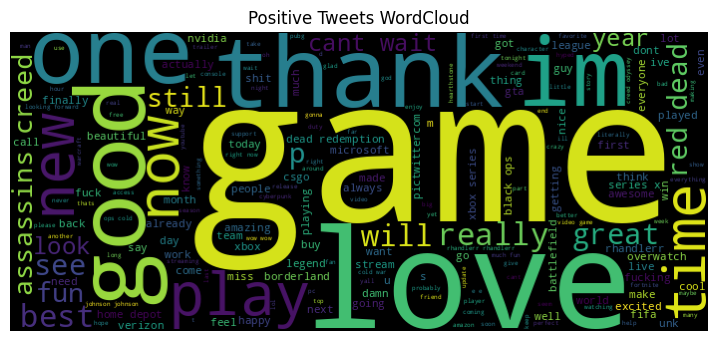

In [47]:
positive_text = ' '.join(train[train['sentiment'] == 'Positive']['text'])
wordcloud = WordCloud(width=700,height=300).generate(positive_text)
plt.figure(figsize=(9,4))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Positive Tweets WordCloud')
plt.show()


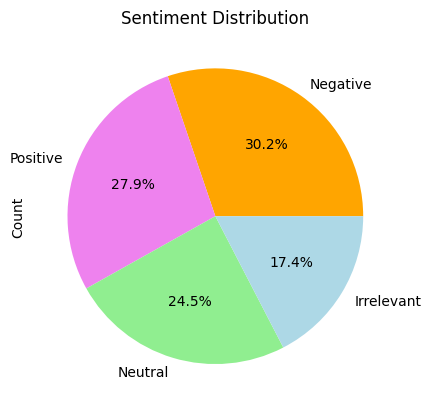

In [57]:
#sentiment count pie chart
train['sentiment'].value_counts().plot(kind='pie' , autopct ='%1.1f%%', colors=['orange','violet','lightgreen','lightblue'])
plt.title('Sentiment Distribution')
plt.ylabel('Count')
plt.show()


## Sentiment Analysis Observations

- Model accuracy: (69.9%)

  Model correctly classified 69.6% of tweets meaning out of 100 tweets it got 70 right and 30 wrong.

- Most tweets were (Negative)

- Positive tweets commonly used words: (Game , Good, Love)

- Naive Bayes worked well for basic text classification
